In [26]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.preprocessing import MinMaxScaler

FEATURE_COLS = ['request_rate', 'cpu_usage', 'latency_p95', 'replica_count']
TARGET_COL = 'replica_count'
TEST_SIZE_RATIO = 0.2
EPOCHS = 200
BATCH_SIZE = 64
DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
SEQ_LENGTH = 10

df = pd.read_csv('../../dataset/training_dataset.csv', index_col=0)
df = df.sort_index()
df = df[df['memory_usage'] > 0]
df = df[~((df['cpu_usage'] == 0) & 
          (df['request_rate'] == 0) & 
          (df['replica_count'] == 0))]
df['replica_count'] = df['replica_count'].replace(0, np.nan).ffill().bfill()
df['cpu_usage'] = df['cpu_usage'].ffill()
df = df.dropna()
df = df.sort_index().reset_index()

print(f"Rows after preprocessing: {len(df)}")
print(f"\nReplica count distribution:")
print(df['replica_count'].value_counts().sort_index())
print(f"\nRows with active traffic: {len(df[df['request_rate'] > 0])}")
print(f"Idle rows: {len(df[df['request_rate'] == 0])}")

data = df[FEATURE_COLS].copy()

split_row = int(len(data) * (1 - TEST_SIZE_RATIO))

scaler = MinMaxScaler()
scaler.fit(data.iloc[:split_row])
scaled_data = scaler.transform(data)

Rows after preprocessing: 4413

Replica count distribution:
replica_count
1.0       1
2.0     154
3.0       5
4.0      28
5.0      77
6.0     255
7.0     607
8.0     448
9.0    2838
Name: count, dtype: int64

Rows with active traffic: 3562
Idle rows: 851


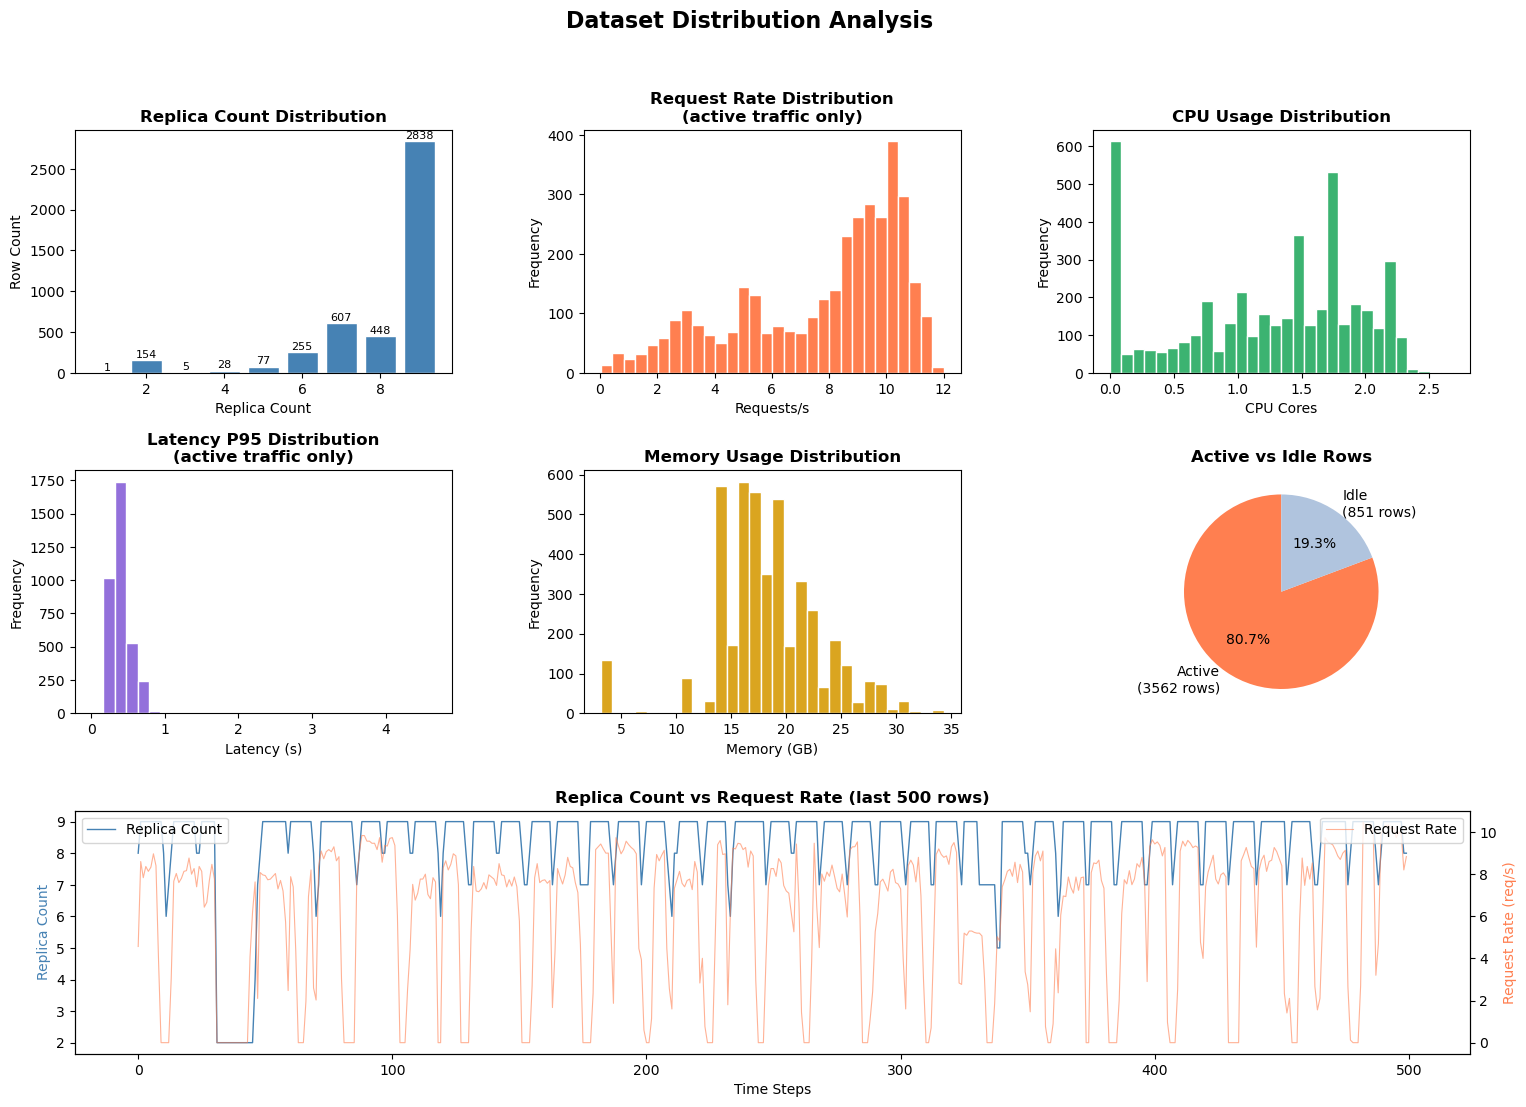


Plot saved to dataset_distribution.png


In [27]:
fig = plt.figure(figsize=(18, 12))
fig.suptitle('Dataset Distribution Analysis', fontsize=16, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.4, wspace=0.35)

# 1. replica count distribution
ax1 = fig.add_subplot(gs[0, 0])
replica_counts = df['replica_count'].value_counts().sort_index()
bars = ax1.bar(replica_counts.index, replica_counts.values, color='steelblue', edgecolor='white')
ax1.set_title('Replica Count Distribution', fontweight='bold')
ax1.set_xlabel('Replica Count')
ax1.set_ylabel('Row Count')
for bar, val in zip(bars, replica_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{val}', ha='center', va='bottom', fontsize=8)

# 2. request rate distribution
ax2 = fig.add_subplot(gs[0, 1])
active = df[df['request_rate'] > 0]['request_rate']
ax2.hist(active, bins=30, color='coral', edgecolor='white')
ax2.set_title('Request Rate Distribution\n(active traffic only)', fontweight='bold')
ax2.set_xlabel('Requests/s')
ax2.set_ylabel('Frequency')

# 3. cpu usage distribution
ax3 = fig.add_subplot(gs[0, 2])
ax3.hist(df['cpu_usage'], bins=30, color='mediumseagreen', edgecolor='white')
ax3.set_title('CPU Usage Distribution', fontweight='bold')
ax3.set_xlabel('CPU Cores')
ax3.set_ylabel('Frequency')

# 4. latency p95 distribution (active traffic only)
ax4 = fig.add_subplot(gs[1, 0])
active_lat = df[df['latency_p95'] > 0]['latency_p95']
ax4.hist(active_lat, bins=30, color='mediumpurple', edgecolor='white')
ax4.set_title('Latency P95 Distribution\n(active traffic only)', fontweight='bold')
ax4.set_xlabel('Latency (s)')
ax4.set_ylabel('Frequency')

# 5. memory usage distribution
ax5 = fig.add_subplot(gs[1, 1])
ax5.hist(df['memory_usage'] / 1e9, bins=30, color='goldenrod', edgecolor='white')
ax5.set_title('Memory Usage Distribution', fontweight='bold')
ax5.set_xlabel('Memory (GB)')
ax5.set_ylabel('Frequency')

# 6. idle vs active pie
ax6 = fig.add_subplot(gs[1, 2])
idle = len(df[df['request_rate'] == 0])
active_rows = len(df[df['request_rate'] > 0])
ax6.pie([active_rows, idle],
        labels=[f'Active\n({active_rows} rows)', f'Idle\n({idle} rows)'],
        colors=['coral', 'lightsteelblue'],
        autopct='%1.1f%%', startangle=90)
ax6.set_title('Active vs Idle Rows', fontweight='bold')

# 7. scaling events — replica count over time (sample of 500 rows)
ax7 = fig.add_subplot(gs[2, :])
sample = df.tail(500) if len(df) > 500 else df
ax7.plot(range(len(sample)), sample['replica_count'],
         color='steelblue', linewidth=1, label='Replica Count')
ax7_twin = ax7.twinx()
ax7_twin.plot(range(len(sample)), sample['request_rate'],
              color='coral', linewidth=0.8, alpha=0.6, label='Request Rate')
ax7.set_title('Replica Count vs Request Rate (last 500 rows)', fontweight='bold')
ax7.set_xlabel('Time Steps')
ax7.set_ylabel('Replica Count', color='steelblue')
ax7_twin.set_ylabel('Request Rate (req/s)', color='coral')
ax7.legend(loc='upper left')
ax7_twin.legend(loc='upper right')

plt.savefig('dataset_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot saved to dataset_distribution.png")

In [28]:
HORIZON = 1  
target_idx = FEATURE_COLS.index(TARGET_COL)

def create_sequences(data, seq_length, target_idx, horizon=HORIZON):
    X, y = [], []
    for i in range(len(data) - seq_length - horizon):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length + horizon, target_idx])
    return np.array(X), np.array(y)


X_seq, y_seq = create_sequences(scaled_data, SEQ_LENGTH, target_idx)

split = int(len(X_seq) * (1 - TEST_SIZE_RATIO))
X_train, X_test = X_seq[:split], X_seq[split:]
y_train, y_test = y_seq[:split], y_seq[split:]



In [29]:
class K8sDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(-1)

    def __len__(self): return len(self.X)

    def __getitem__(self, idx): return self.X[idx], self.y[idx]


train_loader = DataLoader(K8sDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)  
test_loader = DataLoader(K8sDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False)



In [30]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=len(FEATURE_COLS), hidden_size=64, num_layers=2, dropout=0.15):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                            batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])


In [32]:
model = LSTMModel().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0008)
loss_fn = nn.MSELoss()

MODEL_SAVE_PATH = "best_lstm_model.pt"

print("Epoch   | Train Loss | Val Loss | RMSE    | MAE     | R²")
print("-" * 58)

best_val_loss = float('inf') # Inițializăm cu infinit
best_epoch = 0

for epoch in range(EPOCHS):
    model.train()
    total_train_loss = 0
    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        pred = model(x)
        loss = loss_fn(pred, y)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item() * x.size(0)
    train_loss = total_train_loss / len(train_loader.dataset)

    model.eval()
    total_val_loss = 0
    preds, trues = [], []
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            out = model(x)
            v_loss = loss_fn(out, y)
            total_val_loss += v_loss.item() * x.size(0)
            
            preds.append(out.cpu().numpy())
            trues.append(y.cpu().numpy())

    val_loss = total_val_loss / len(test_loader.dataset)
    
    preds = np.concatenate(preds).ravel()
    trues = np.concatenate(trues).ravel()
    
    dummy = np.zeros((len(preds), len(FEATURE_COLS)))
    dummy[:, target_idx] = preds
    pred_unscaled = scaler.inverse_transform(dummy)[:, target_idx]

    dummy[:, target_idx] = trues
    true_unscaled = scaler.inverse_transform(dummy)[:, target_idx]

    pred_final = np.round(np.clip(pred_unscaled, 0, None))
    
    rmse = np.sqrt(mean_squared_error(true_unscaled, pred_final))
    mae = mean_absolute_error(true_unscaled, pred_final)
    r2 = r2_score(true_unscaled, pred_final)

    print(f"{epoch + 1:2d}/{EPOCHS}   {train_loss:.5f}   {val_loss:.5f}   {rmse:.4f}   {mae:.4f}   {r2:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch + 1
        torch.save({
            'epoch': best_epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': best_val_loss,
            'r2': r2,
            'scaler': scaler
        }, MODEL_SAVE_PATH)

print(f"\nFinalizat! Cel mai bun model a fost la epoca {best_epoch} cu Val Loss: {best_val_loss:.6f}")

Epoch   | Train Loss | Val Loss | RMSE    | MAE     | R²
----------------------------------------------------------
 1/200   0.13972   0.05164   1.8065   1.2928   -1.2935
 2/200   0.03426   0.04865   1.7786   1.2316   -1.2233
 3/200   0.03122   0.04866   1.7668   1.2372   -1.1938
 4/200   0.02919   0.04398   1.7106   0.9625   -1.0565
 5/200   0.02739   0.04290   1.6986   0.9784   -1.0278
 6/200   0.02608   0.04291   1.7020   1.0988   -1.0358
 7/200   0.02542   0.03953   1.6161   0.9024   -0.8356
 8/200   0.02436   0.03835   1.5949   0.8933   -0.7877
 9/200   0.02346   0.04172   1.6622   1.1033   -0.9417
10/200   0.02588   0.03655   1.5531   0.8365   -0.6952
11/200   0.02247   0.03566   1.5424   0.8377   -0.6720
12/200   0.02229   0.03615   1.5432   0.8536   -0.6736
13/200   0.02254   0.04403   1.6976   1.2474   -1.0254
14/200   0.02541   0.03510   1.5461   1.0102   -0.6800
15/200   0.02154   0.03254   1.4643   0.7616   -0.5069
16/200   0.02190   0.03364   1.5090   1.0057   -0.6002
17/2

*Sample test for lstm prediction*

          timestamp  request_rate    cpu_usage  memory_usage  \
count  7.019000e+03   7019.000000  6964.000000  7.019000e+03   
mean   1.776162e+09      5.868512     1.193299  1.752260e+10   
std    1.088896e+06      3.985363     0.727766  5.033459e+09   
min    1.774793e+09      0.000000     0.000000  0.000000e+00   
25%    1.775223e+09      1.901060     0.624193  1.500344e+10   
50%    1.775328e+09      7.133333     1.391666  1.756921e+10   
75%    1.777293e+09      9.432324     1.748208  2.042248e+10   
max    1.777664e+09     12.000403     2.682935  3.523565e+10   

       cpu_throttling_ratio  latency_p95  error_rate  replica_count  
count                7019.0  7019.000000      7019.0    7019.000000  
mean                    0.0     0.344284         0.0       7.701809  
std                     0.0     0.251751         0.0       2.369082  
min                     0.0     0.000000         0.0       0.000000  
25%                     0.0     0.241339         0.0       7.000000  
50%